# Analysis and plots of the Cost of Politness energy study

## Energy cost of a simple thank you (Llama-3.1-8B-Instruct)

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

FOLDER = "./data/"
CSV_FILE = "Llama-3.1-8B-Instruct-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-energy-2025-05-31-10-44-37.csv"
df = pd.read_csv(FOLDER + CSV_FILE)
df

,Unnamed: 0,model,dataset,split,column,prompt_tokens,response_tokens,duration_prefill,duration_generate,duration_decode,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,energy_generate_cpu,energy_generate_gpu,energy_generate_ram,energy_decode_cpu,energy_decode_gpu,energy_decode_ram
0,0,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,683,47,0.243993,1.374374,1.130381,0.000004,0.000043,0.000003,0.000018,0.000141,0.000015,0.000014,0.000098,0.000012
1,1,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,1488,45,0.499466,1.581464,1.081998,0.000007,0.000089,0.000006,0.000020,0.000196,0.000017,0.000014,0.000108,0.000011
2,2,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,2999,69,0.956044,2.804570,1.848526,0.000013,0.000178,0.000011,0.000036,0.000374,0.000030,0.000023,0.000196,0.000020
3,3,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,410,38,0.147575,1.058437,0.910862,0.000002,0.000031,0.000002,0.000014,0.000110,0.000012,0.000011,0.000080,0.000010
4,4,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,2156,53,0.764414,2.056390,1.291976,0.000010,0.000143,0.000009,0.000026,0.000281,0.000022,0.000016,0.000138,0.000014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,966,37,0.332717,1.244684,0.911968,0.000005,0.000066,0.000004,0.000017,0.000148,0.000014,0.000012,0.000082,0.000010
9996,9996,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,1308,39,0.428730,1.405598,0.976868,0.000006,0.000084,0.000005,0.000019,0.000178,0.000015,0.000013,0.000094,0.000010
9997,9997,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,790,81,0.264035,2.354033,2.089998,0.000004,0.000052,0.000003,0.000031,0.000236,0.000025,0.000027,0.000184,0.000022
9998,9998,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,482,18,0.166148,0.589201,0.423053,0.000003,0.000032,0.000002,0.000008,0.000069,0.000007,0.000006,0.000037,0.000004


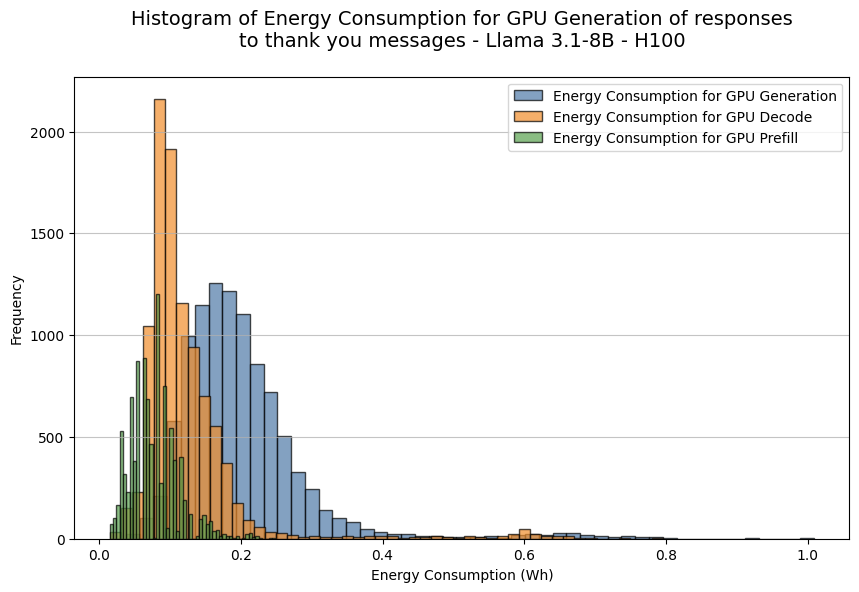

In [2]:
plt.figure(figsize=(10, 6))
colors = ['#4E79A7', '#F28E2B', '#59A14F']
plt.hist(df['energy_generate_gpu']*1000, bins=50, alpha=0.7, edgecolor='black', label='Energy Consumption for GPU Generation', color=colors[0])
plt.hist(df['energy_decode_gpu']*1000, bins=50, alpha=0.7, edgecolor='black', label='Energy Consumption for GPU Decode', color=colors[1])
plt.hist(df['energy_prefill_gpu']*1000, bins=50, alpha=0.7, edgecolor='black', label='Energy Consumption for GPU Prefill', color=colors[2])
plt.legend(loc='upper right')
plt.title('Histogram of Energy Consumption for GPU Generation of responses\nto thank you messages - Llama 3.1-8B - H100\n', fontsize=14)
plt.xlabel('Energy Consumption (Wh)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

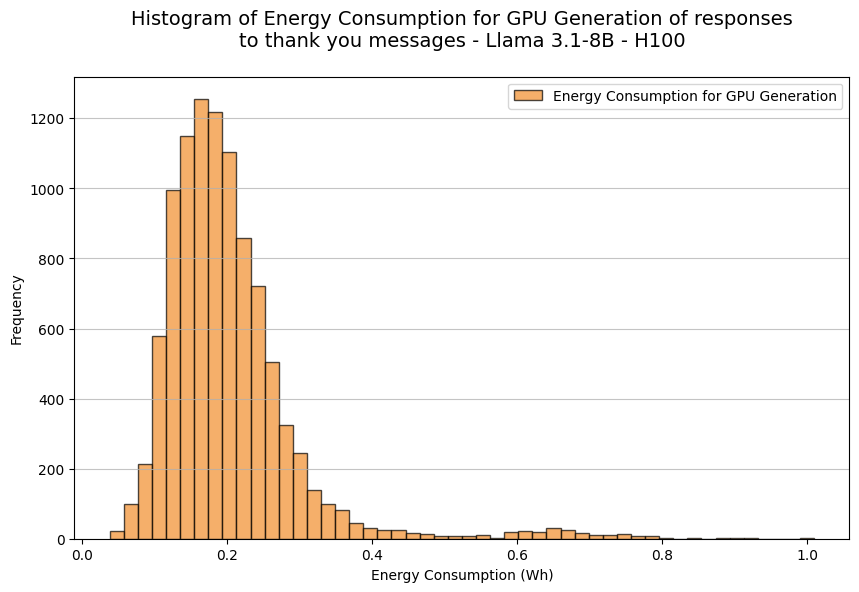

In [3]:
plt.figure(figsize=(10, 6))
colors = ['#4E79A7', '#F28E2B', '#59A14F']
plt.hist(df['energy_generate_gpu']*1000, bins=50, alpha=0.7, edgecolor='black', label='Energy Consumption for GPU Generation', color=colors[1])
plt.legend(loc='upper right')
plt.title('Histogram of Energy Consumption for GPU Generation of responses\nto thank you messages - Llama 3.1-8B - H100\n', fontsize=14)
plt.xlabel('Energy Consumption (Wh)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Energy Cost Component wise

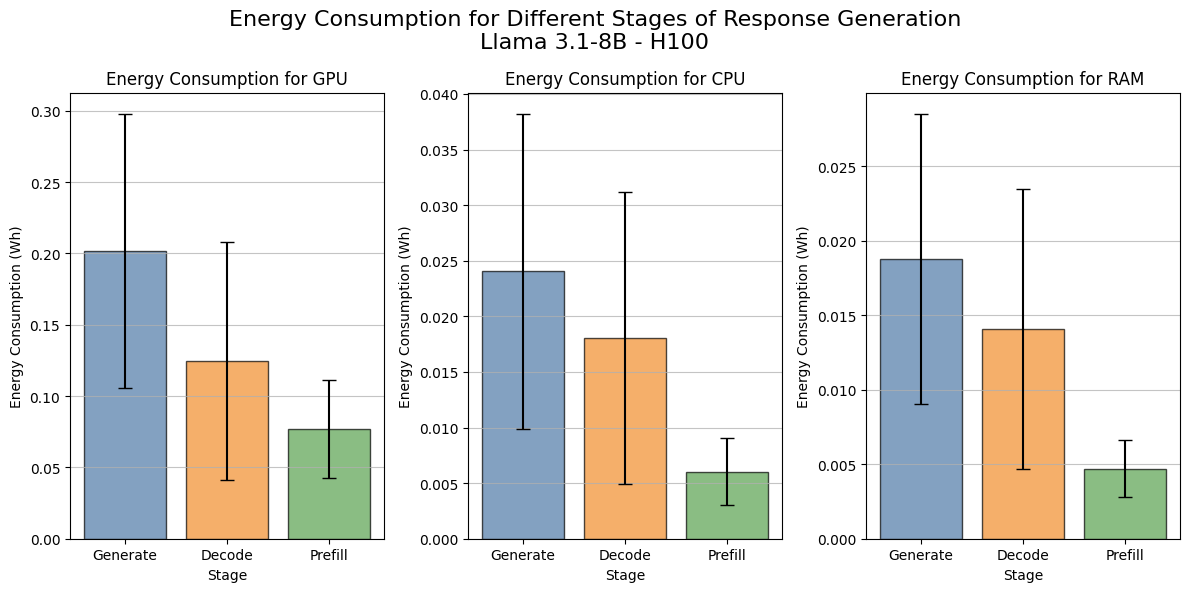

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
x_pos = np.arange(3)
colors = ['#4E79A7', '#F28E2B', '#59A14F']

for i, device in enumerate(['gpu', 'cpu', 'ram']):
    ax[i].bar(x_pos,
            [df[f'energy_generate_{device}'].mean()*1000, df[f'energy_decode_{device}'].mean()*1000, df[f'energy_prefill_{device}'].mean()*1000],
            yerr=[df[f'energy_generate_{device}'].std()*1000, df[f'energy_decode_{device}'].std()*1000, df[f'energy_prefill_{device}'].std()*1000],
            capsize=5, color=colors, alpha=0.7, edgecolor='black')
    ax[i].set_xticks(x_pos)
    ax[i].set_xticklabels(['Generate', 'Decode', 'Prefill'])
    ax[i].set_ylabel('Energy Consumption (Wh)')
    ax[i].set_xlabel('Stage')
    ax[i].grid(axis='y', alpha=0.75)
    ax[i].set_title(f'Energy Consumption for {device.upper()}')
ax[0].set_title('Energy Consumption for GPU')
ax[1].set_title('Energy Consumption for CPU')
ax[2].set_title('Energy Consumption for RAM')
plt.suptitle('Energy Consumption for Different Stages of Response Generation\nLlama 3.1-8B - H100', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.tight_layout()
plt.show()

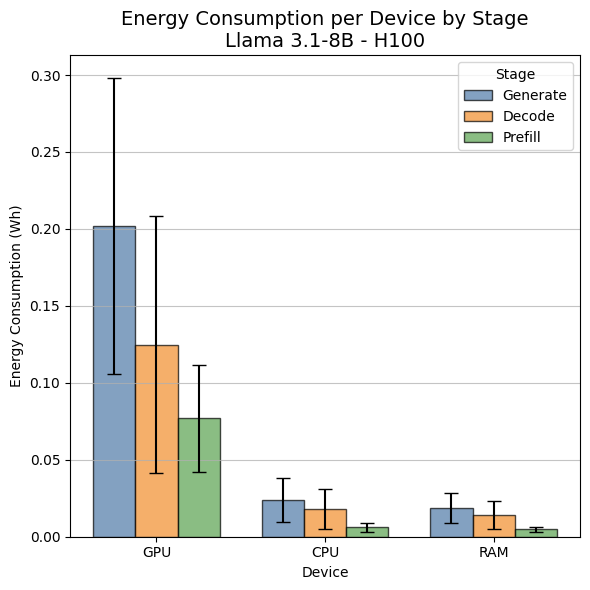

In [5]:
devices = ['gpu', 'cpu', 'ram']
stages = ['Generate', 'Decode', 'Prefill']
colors = {'Generate': 'blue', 'Decode': 'green', 'Prefill': 'orange'}
colors = ['#4E79A7', '#F28E2B', '#59A14F']

x = np.arange(len(devices))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 6))

for i, stage in enumerate(stages):
    means = [df[f'energy_{stage.lower()}_{device}'].mean() * 1000 for device in devices]
    stds = [df[f'energy_{stage.lower()}_{device}'].std() * 1000 for device in devices]
    ax.bar(x + (i - 1) * width, means, width, yerr=stds, capsize=5,
           label=stage, alpha=0.7, edgecolor='black', color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([d.upper() for d in devices])
ax.set_ylabel('Energy Consumption (Wh)')
ax.set_xlabel('Device')
ax.set_title('Energy Consumption per Device by Stage\nLlama 3.1-8B - H100', fontsize=14)
ax.grid(axis='y', alpha=0.75)
ax.legend(title='Stage')
plt.tight_layout()
plt.show()

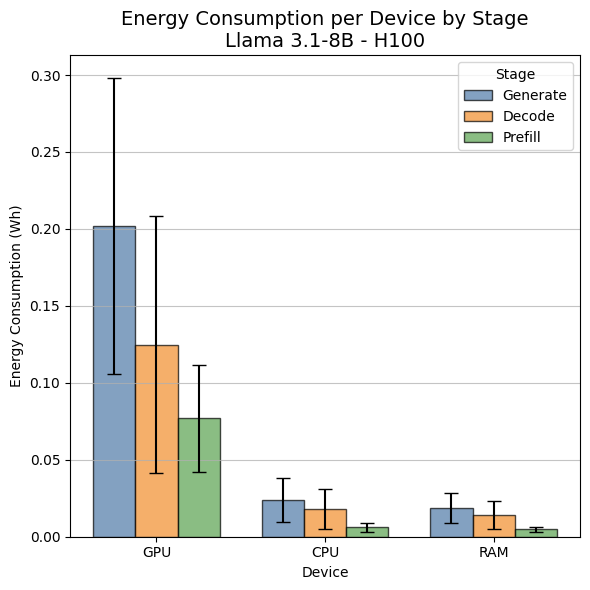

In [6]:
devices = ['gpu', 'cpu', 'ram']
stages = ['Generate', 'Decode', 'Prefill']
colors = {'Generate': 'blue', 'Decode': 'green', 'Prefill': 'orange'}
colors = ['#4E79A7', '#F28E2B', '#59A14F']

x = np.arange(len(devices))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 6))

for i, stage in enumerate(stages):
    means = [df[f'energy_{stage.lower()}_{device}'].mean() * 1000 for device in devices]
    stds = [df[f'energy_{stage.lower()}_{device}'].std() * 1000 for device in devices]
    ax.bar(x + (i - 1) * width, means, width, yerr=stds, capsize=5,
           label=stage, alpha=0.7, edgecolor='black', color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([d.upper() for d in devices])
ax.set_ylabel('Energy Consumption (Wh)')
ax.set_xlabel('Device')
ax.set_title('Energy Consumption per Device by Stage\nLlama 3.1-8B - H100', fontsize=14)
ax.grid(axis='y', alpha=0.75)
ax.legend(title='Stage')
plt.tight_layout()
plt.show()

## Input/Output Energy dependance

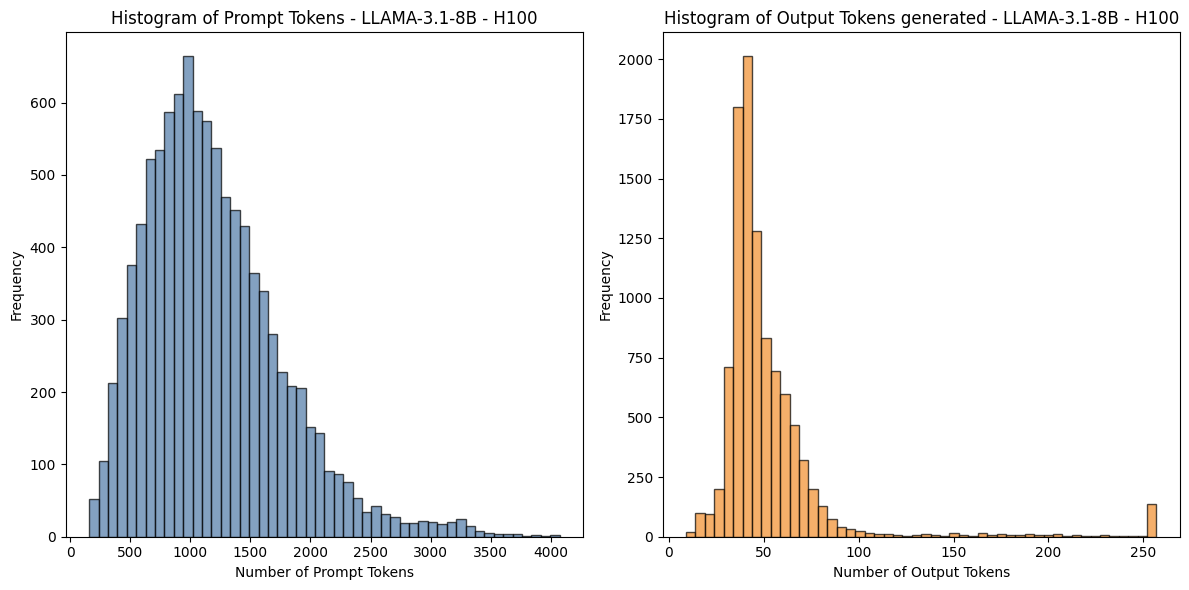

In [7]:
colors = ['#4E79A7', '#F28E2B', '#59A14F']
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].hist(df['prompt_tokens'], bins=50, alpha=0.7, edgecolor='black', color=colors[0])
ax[0].set_title('Histogram of Prompt Tokens - LLAMA-3.1-8B - H100')
ax[0].set_xlabel('Number of Prompt Tokens')
ax[0].set_ylabel('Frequency')
ax[1].hist(df['response_tokens'], bins=50, alpha=0.7, edgecolor='black', color=colors[1])
ax[1].set_title('Histogram of Output Tokens generated - LLAMA-3.1-8B - H100')
ax[1].set_xlabel('Number of Output Tokens')
ax[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


In [8]:
print(f"min prompt tokens: {df['prompt_tokens'].min()}")
print(f"max prompt tokens: {df['prompt_tokens'].max()}")
print(f"min response tokens: {df['response_tokens'].min()}")
print(f"max response tokens: {df['response_tokens'].max()}")
print(f"mean prompt tokens: {df['prompt_tokens'].mean()}")
print(f"mean response tokens: {df['response_tokens'].mean()}")
print(f"std prompt tokens: {df['prompt_tokens'].std()}")
print(f"std response tokens: {df['response_tokens'].std()}")

min prompt tokens: 159
max prompt tokens: 4073
min response tokens: 9
max response tokens: 257
mean prompt tokens: 1189.7714
mean response tokens: 52.315
std prompt tokens: 570.9830716482328
std response tokens: 33.49720258854649


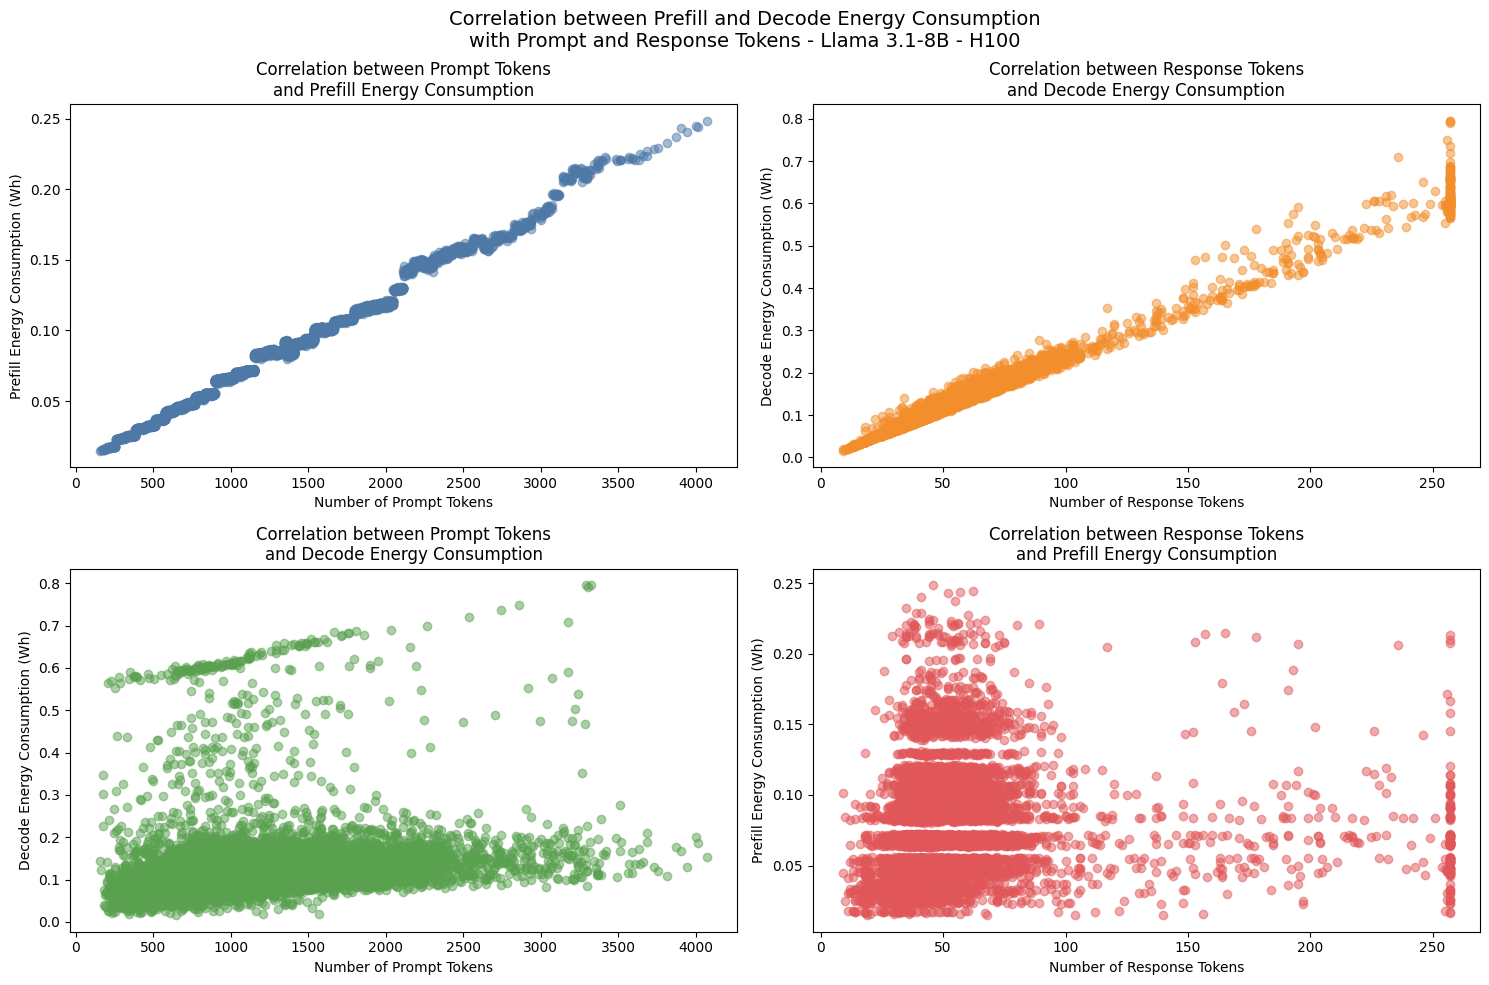

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']
ax[0, 0].scatter(df['prompt_tokens'], df['energy_prefill_gpu']*1000, alpha=0.5, color=colors[0])
ax[0, 0].set_title('Correlation between Prompt Tokens\nand Prefill Energy Consumption')
ax[0, 0].set_xlabel('Number of Prompt Tokens')
ax[0, 0].set_ylabel('Prefill Energy Consumption (Wh)')
ax[0, 1].scatter(df['response_tokens'], df['energy_decode_gpu']*1000, alpha=0.5, color=colors[1])
ax[0, 1].set_title('Correlation between Response Tokens\nand Decode Energy Consumption')
ax[0, 1].set_xlabel('Number of Response Tokens')
ax[0, 1].set_ylabel('Decode Energy Consumption (Wh)')
ax[1, 0].scatter(df['prompt_tokens'], df['energy_decode_gpu']*1000, alpha=0.5, color=colors[2])
ax[1, 0].set_title('Correlation between Prompt Tokens\nand Decode Energy Consumption')
ax[1, 0].set_xlabel('Number of Prompt Tokens')
ax[1, 0].set_ylabel('Decode Energy Consumption (Wh)')
ax[1, 1].scatter(df['response_tokens'], df['energy_prefill_gpu']*1000, alpha=0.5, color=colors[3])
ax[1, 1].set_title('Correlation between Response Tokens\nand Prefill Energy Consumption')
ax[1, 1].set_xlabel('Number of Response Tokens')
ax[1, 1].set_ylabel('Prefill Energy Consumption (Wh)')
plt.suptitle('Correlation between Prefill and Decode Energy Consumption\nwith Prompt and Response Tokens - Llama 3.1-8B - H100', fontsize=14)
plt.tight_layout()
plt.show()


### Fitting models on Energy plots

Equation for Correlation between Prompt Tokens
and Prefill Energy Consumption: y = 0.000060x + 0.004997
Equation for Correlation between Response Tokens
and Decode Energy Consumption: y = 0.002467x + -0.004243
Equation for Correlation between Prompt Tokens
and Decode Energy Consumption: y = 0.000028x + 0.091768
Equation for Correlation between Response Tokens
and Prefill Energy Consumption: y = 0.000088x + 0.072347


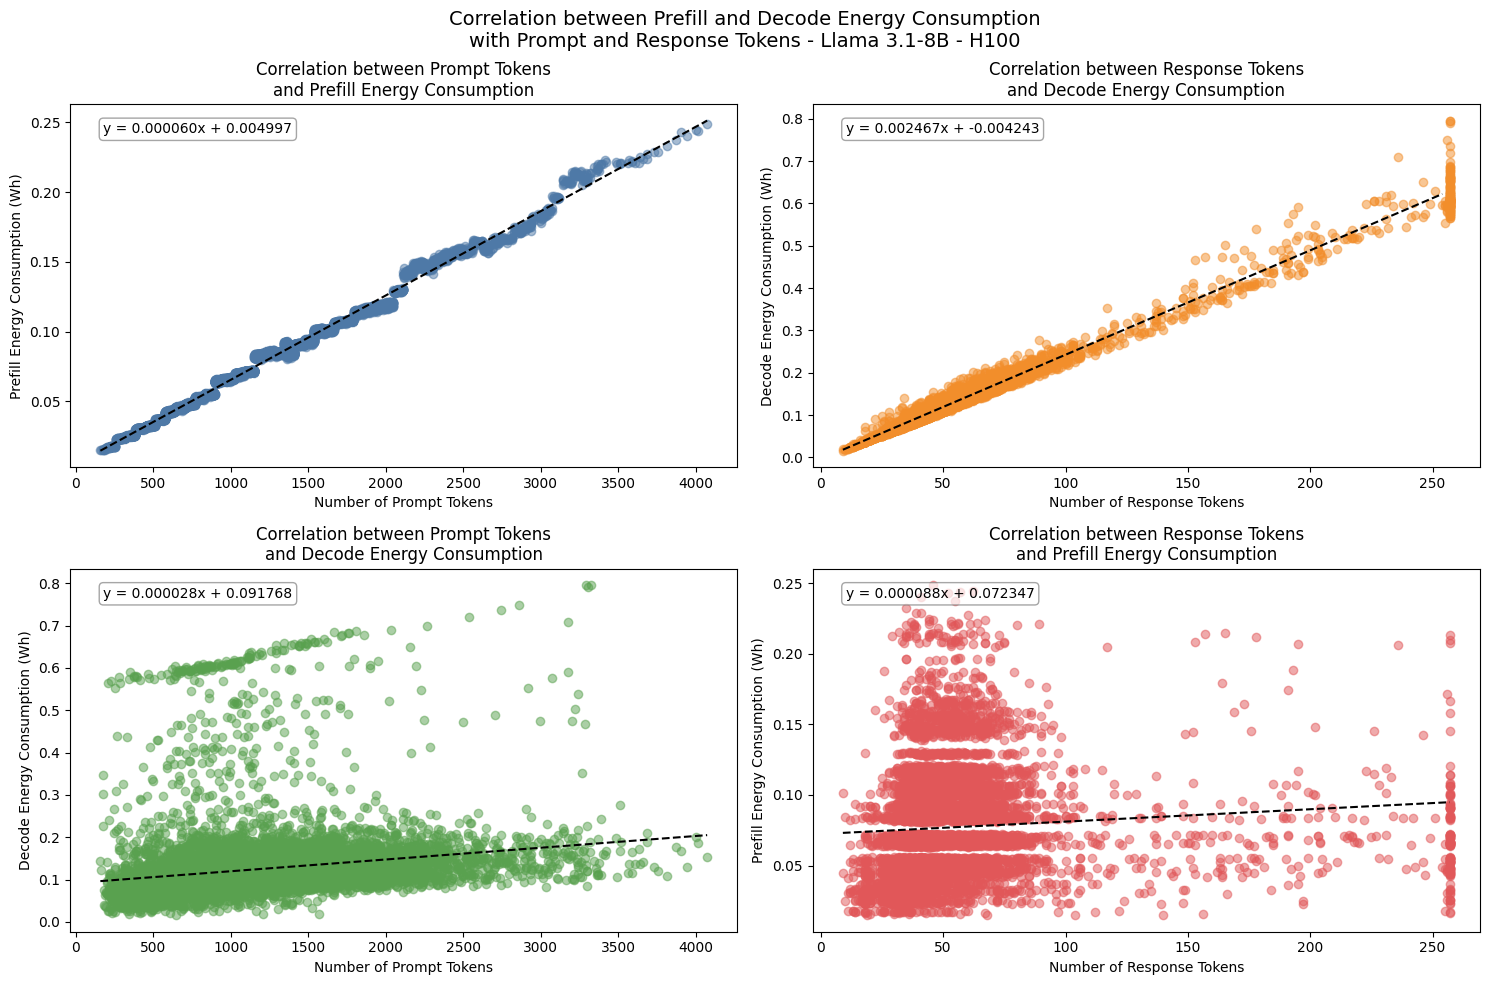

In [12]:
from sklearn.linear_model import LinearRegression

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']

pairs = [
    (df['prompt_tokens'], df['energy_prefill_gpu']*1000, ax[0, 0], colors[0], 'Correlation between Prompt Tokens\nand Prefill Energy Consumption', 'Number of Prompt Tokens', 'Prefill Energy Consumption (Wh)'),
    (df['response_tokens'], df['energy_decode_gpu']*1000, ax[0, 1], colors[1], 'Correlation between Response Tokens\nand Decode Energy Consumption', 'Number of Response Tokens', 'Decode Energy Consumption (Wh)'),
    (df['prompt_tokens'], df['energy_decode_gpu']*1000, ax[1, 0], colors[2], 'Correlation between Prompt Tokens\nand Decode Energy Consumption', 'Number of Prompt Tokens', 'Decode Energy Consumption (Wh)'),
    (df['response_tokens'], df['energy_prefill_gpu']*1000, ax[1, 1], colors[3], 'Correlation between Response Tokens\nand Prefill Energy Consumption', 'Number of Response Tokens', 'Prefill Energy Consumption (Wh)')
]

for x, y, axis, color, title, xlabel, ylabel in pairs:
    axis.scatter(x, y, alpha=0.5, color=color)
    model = LinearRegression()
    model.fit(x.values.reshape(-1, 1), y.values)
    a = model.coef_[0]
    b = model.intercept_
    
    if 'Correlation between Response Tokens\nand Decode Energy Consumption' in title:
        x_limit = 254
    else:
        x_limit = x.max()
    x_range = np.linspace(x.min(), x_limit, 100)
    y_pred = model.predict(x_range.reshape(-1, 1))
    axis.plot(x_range, y_pred, color='black', linestyle='--')
    
    eq_text = f'y = {a:.6f}x + {b:.6f}'
    print(f'Equation for {title}: {eq_text}')
    axis.text(0.05, 0.95, eq_text, transform=axis.transAxes,
              fontsize=10, verticalalignment='top',
              bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)

plt.suptitle('Correlation between Prefill and Decode Energy Consumption\nwith Prompt and Response Tokens - Llama 3.1-8B - H100', fontsize=14)
plt.tight_layout()
plt.show()


#### Model fit Energy Prefill

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

## DEGRE 2 FIT
# t_prefill = αs + βs² + γ
x_prefill = df['prompt_tokens'].values.reshape(-1, 1)
y_prefill = df['energy_prefill_gpu'].values * 1000  # Convert to Wh

model_poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_poly.fit(x_prefill, y_prefill)

C = model_poly.named_steps['linearregression'].intercept_
A, B = model_poly.named_steps['linearregression'].coef_[1:3]

print(f"E_prefill(s) ≈ {A:.2e} * s + {B:.2e} * s² + {C:.2e}")

## DEGRE 1 FIT
# t_prefill = αs + γ
x_prefill = df['prompt_tokens'].values.reshape(-1, 1)
y_prefill = df['energy_prefill_gpu'].values * 1000  # Convert to Wh

model_linear = make_pipeline(PolynomialFeatures(1), LinearRegression())
model_linear.fit(x_prefill, y_prefill)

B = model_linear.named_steps['linearregression'].intercept_
A = model_linear.named_steps['linearregression'].coef_[1]

print(f"E_prefill(s) ≈ {A:.2e} * s + {B:.2e}")

E_prefill(s) ≈ 5.96e-05 * s + 3.02e-10 * s² + 5.54e-03
E_prefill(s) ≈ 6.05e-05 * s + 5.00e-03


#### Model Fit Energy Decode

In [14]:
s = df['prompt_tokens'].values
g = df['response_tokens'].values
y = df['energy_decode_gpu'].values * 1000  # kWh -> Wh

X = np.stack([
    np.ones_like(s),
    g,
    s * g
], axis=1)

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

E, C, D = model.coef_

print(f"Fit: E_decode(s, g) ≈ {E:.2e} + {C:.2e} * g + {D:.2e} * s·g   (Wh)")


Fit: E_decode(s, g) ≈ -4.71e-03 + 2.13e-03 * g + 2.87e-07 * s·g   (Wh)


### Fitting models on latency plots

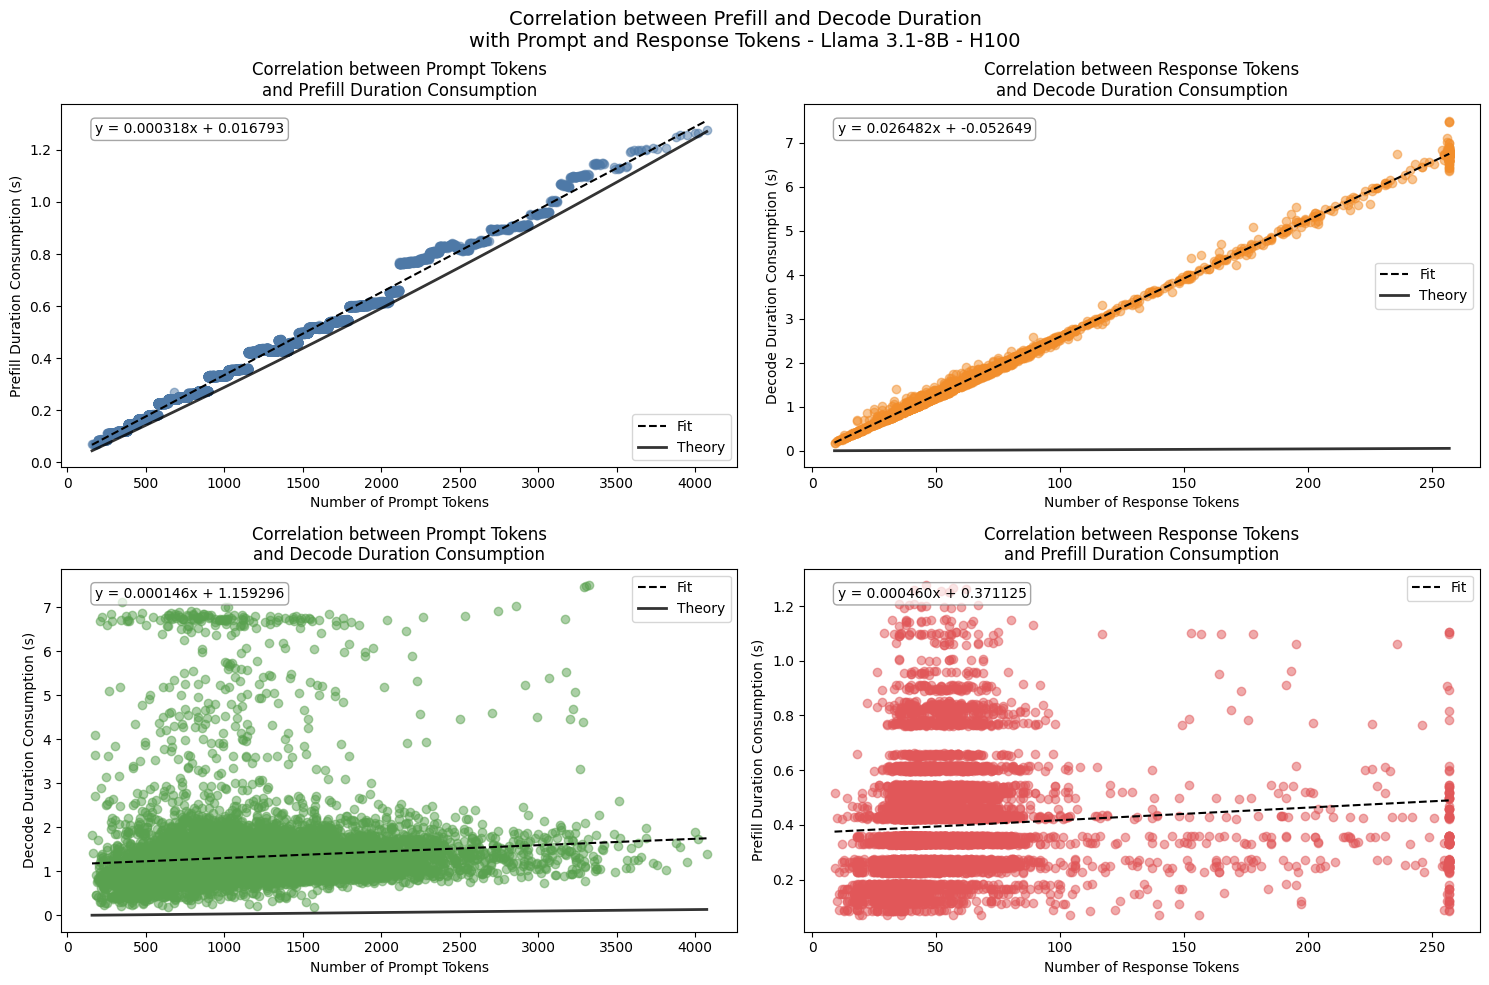

In [16]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lambda_ = 7.83e-8*128

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']

pairs = [
    (df['prompt_tokens'], df['duration_prefill'], ax[0, 0], colors[0],
     'Correlation between Prompt Tokens\nand Prefill Duration Consumption',
     'Number of Prompt Tokens', 'Prefill Duration Consumption (s)', 'prefill'),

    (df['response_tokens'], df['duration_decode'], ax[0, 1], colors[1],
     'Correlation between Response Tokens\nand Decode Duration Consumption',
     'Number of Response Tokens', 'Decode Duration Consumption (s)', 'decode_g'),

    (df['prompt_tokens'], df['duration_decode'], ax[1, 0], colors[2],
     'Correlation between Prompt Tokens\nand Decode Duration Consumption',
     'Number of Prompt Tokens', 'Decode Duration Consumption (s)', 'decode_s'),

    (df['response_tokens'], df['duration_prefill'], ax[1, 1], colors[3],
     'Correlation between Response Tokens\nand Prefill Duration Consumption',
     'Number of Response Tokens', 'Prefill Duration Consumption (s)', 'none')
]

for x, y, axis, color, title, xlabel, ylabel, mode in pairs:
    # Scatter
    axis.scatter(x, y, alpha=0.5, color=color)

    # Fit linéaire
    model = LinearRegression()
    model.fit(x.values.reshape(-1, 1), y.values)
    a = model.coef_[0]
    b = model.intercept_
    x_range = np.linspace(x.min(), x.max(), 100)
    y_pred = model.predict(x_range.reshape(-1, 1))
    axis.plot(x_range, y_pred, color='black', linestyle='--', label="Fit")

    # Théorie (selon le cas) 1.68e-04 s + 7.83e-09 s^2
    gamma = 1.68e-04/0.6     # s/token
    eta = 7.83e-09           # s/token²
    if mode == 'prefill':
        y_theory = gamma * x_range + eta * x_range**2
        axis.plot(x_range, y_theory, color='black', linewidth=2, alpha=0.8, label='Theory')

    elif mode == 'decode_g':
        #6.40\times10^{-3} + 7.83 \times 10^{-7} \cdot s
        delta1 = 2.15e-4
        delta2 = 0 #7.83e-7
        s_used = 2000
        s_ref = df['prompt_tokens'].mean()
        y_theory = delta1 * x_range + delta2 * s_ref
        y_theory2 = delta1 * x_range + delta2 * 0
        axis.plot(x_range, y_theory, color='black', linewidth=2, alpha=0.8, label='Theory')
        #axis.plot(x_range, y_theory2, color='black', linewidth=2, alpha=0.8, label='Theory2')

    elif mode == 'decode_s':
        lambda_ = 7.83e-8*128/0.3
        g_ref = df['response_tokens'].mean()
        y_theory = lambda_ * x_range
        axis.plot(x_range, y_theory, color='black', linewidth=2, alpha=0.8, label='Theory')

    # Affiche l'équation de la régression linéaire
    eq_text = f'y = {a:.6f}x + {b:.6f}'
    axis.text(0.05, 0.95, eq_text, transform=axis.transAxes,
              fontsize=10, verticalalignment='top',
              bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))

    # Labels
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.legend()

plt.suptitle('Correlation between Prefill and Decode Duration\nwith Prompt and Response Tokens - Llama 3.1-8B - H100', fontsize=14)
plt.tight_layout()
plt.show()


#### Model Fit Latency Prefill

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


## DEGRE 2 FITS
# t_prefill = αs + βs² + γ
x_prefill = df['prompt_tokens'].values.reshape(-1, 1)
y_prefill = df['duration_prefill'].values

model_poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_poly.fit(x_prefill, y_prefill)

gamma = model_poly.named_steps['linearregression'].intercept_
alpha, beta = model_poly.named_steps['linearregression'].coef_[1:3]

print(f"t_prefill(s) ≈ {alpha:.2e} * s + {beta:.2e} * s² + {gamma:.2e}")

## DEGRE 1 FIT
# t_prefill = αs + γ
x_prefill = df['prompt_tokens'].values.reshape(-1, 1)
y_prefill = df['duration_prefill'].values

model_linear = make_pipeline(PolynomialFeatures(1), LinearRegression())
model_linear.fit(x_prefill, y_prefill)

gamma = model_linear.named_steps['linearregression'].intercept_
alpha = model_linear.named_steps['linearregression'].coef_[1]

print(f"t_prefill(s) ≈ {alpha:.2e} * s + {gamma:.2e}")


t_prefill(s) ≈ 3.03e-04 * s + 5.12e-09 * s² + 2.60e-02
t_prefill(s) ≈ 3.18e-04 * s + 1.68e-02


#### Model fit Latency Decode

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

s = df['prompt_tokens'].values
g = df['response_tokens'].values
y = df['duration_decode'].values

X = np.stack([
    np.ones_like(s),
    g,
    s * g
], axis=1)

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

rho, eta, theta = model.coef_

print(f"Fit: E_decode(s, g) ≈ {rho:.2e} + {eta:.2e} * g + {theta:.2e} * s·g   (s)")


Fit: E_decode(s, g) ≈ -5.32e-02 + 2.61e-02 * g + 3.31e-07 * s·g   (s)


### Power fitting

In [19]:
Peff_prefill_linear_term = A * 3600 / alpha
Peff_prefill_constant_term = B * 3600 / gamma
print(f"Peff_prefill_linear_term = {Peff_prefill_linear_term:.2f} W")
print(f"Peff_prefill_constant_term = {Peff_prefill_constant_term:.2f} W")

Peff_decode_linear_term = C * 3600 / eta
Peff_decode_constant_term = E * 3600 / rho
Peff_decode_bilinear_term = D * 3600 / theta
print(f"Peff_decode_bilinear_term = {Peff_decode_bilinear_term:.2f} W")
print(f"Peff_decode_linear_term = {Peff_decode_linear_term:.2f} W")
print(f"Peff_decode_constant_term = {Peff_decode_constant_term:.2f} W")

Peff_prefill_linear_term = 684.32 W
Peff_prefill_constant_term = 1071.32 W
Peff_decode_bilinear_term = 3120.18 W
Peff_decode_linear_term = 293.35 W
Peff_decode_constant_term = 318.82 W


## Multiple models comparison

In [4]:
FOLDER = "./data/"
df_llama8B = pd.read_csv(FOLDER + "Llama-3.1-8B-Instruct-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-energy-2025-05-31-10-44-37.csv")
df_mistral7B = pd.read_csv(FOLDER + "Mistral-7B-Instruct-v0.3-ultrachat_200k-Mistral-7B-Instruct-v0.3-with-thanks-energy-2025-05-31-11-09-48.csv")
df_qwen0_5B = pd.read_csv(FOLDER + "Qwen2.5-0.5B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-21-09.csv")
df_qwen1_5B = pd.read_csv(FOLDER + "Qwen2.5-1.5B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-23-22.csv")
df_qwen3B = pd.read_csv(FOLDER + "Qwen2.5-3B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-23-22.csv")
df_qwen7B = pd.read_csv(FOLDER + "Qwen2.5-7B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-20-03.csv")
df_qwen14B = pd.read_csv(FOLDER + "Qwen2.5-14B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-24-26.csv")
df_all_models = pd.concat([
    df_llama8B,
    df_mistral7B,
    df_qwen0_5B,
    df_qwen1_5B,
    df_qwen3B,
    df_qwen7B,
    df_qwen14B
], ignore_index=True)
df_all_models

,Unnamed: 0,model,dataset,split,column,prompt_tokens,response_tokens,duration_prefill,duration_generate,duration_decode,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,energy_generate_cpu,energy_generate_gpu,energy_generate_ram,energy_decode_cpu,energy_decode_gpu,energy_decode_ram
0,0,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,683,47,0.243993,1.374374,1.130381,0.000004,0.000043,0.000003,0.000018,0.000141,0.000015,0.000014,0.000098,0.000012
1,1,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,1488,45,0.499466,1.581464,1.081998,0.000007,0.000089,0.000006,0.000020,0.000196,0.000017,0.000014,0.000108,0.000011
2,2,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,2999,69,0.956044,2.804570,1.848526,0.000013,0.000178,0.000011,0.000036,0.000374,0.000030,0.000023,0.000196,0.000020
3,3,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,410,38,0.147575,1.058437,0.910862,0.000002,0.000031,0.000002,0.000014,0.000110,0.000012,0.000011,0.000080,0.000010
4,4,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,2156,53,0.764414,2.056390,1.291976,0.000010,0.000143,0.000009,0.000026,0.000281,0.000022,0.000016,0.000138,0.000014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,9995,Qwen/Qwen2.5-14B-Instruct,jdelavande/ultrachat_200k-Qwen2.5-7B-Instruct-...,train,conversation_with_thanks,977,47,0.660163,2.480270,1.820107,0.000009,0.000124,0.000008,0.000032,0.000302,0.000027,0.000023,0.000179,0.000019
69996,9996,Qwen/Qwen2.5-14B-Instruct,jdelavande/ultrachat_200k-Qwen2.5-7B-Instruct-...,train,conversation_with_thanks,1337,20,0.835485,1.579685,0.744200,0.000011,0.000155,0.000009,0.000021,0.000237,0.000017,0.000010,0.000082,0.000008
69997,9997,Qwen/Qwen2.5-14B-Instruct,jdelavande/ultrachat_200k-Qwen2.5-7B-Instruct-...,train,conversation_with_thanks,788,26,0.502417,1.485964,0.983547,0.000007,0.000094,0.000006,0.000024,0.000189,0.000016,0.000017,0.000096,0.000010
69998,9998,Qwen/Qwen2.5-14B-Instruct,jdelavande/ultrachat_200k-Qwen2.5-7B-Instruct-...,train,conversation_with_thanks,479,19,0.316996,1.020644,0.703648,0.000005,0.000061,0.000004,0.000013,0.000127,0.000011,0.000009,0.000066,0.000007


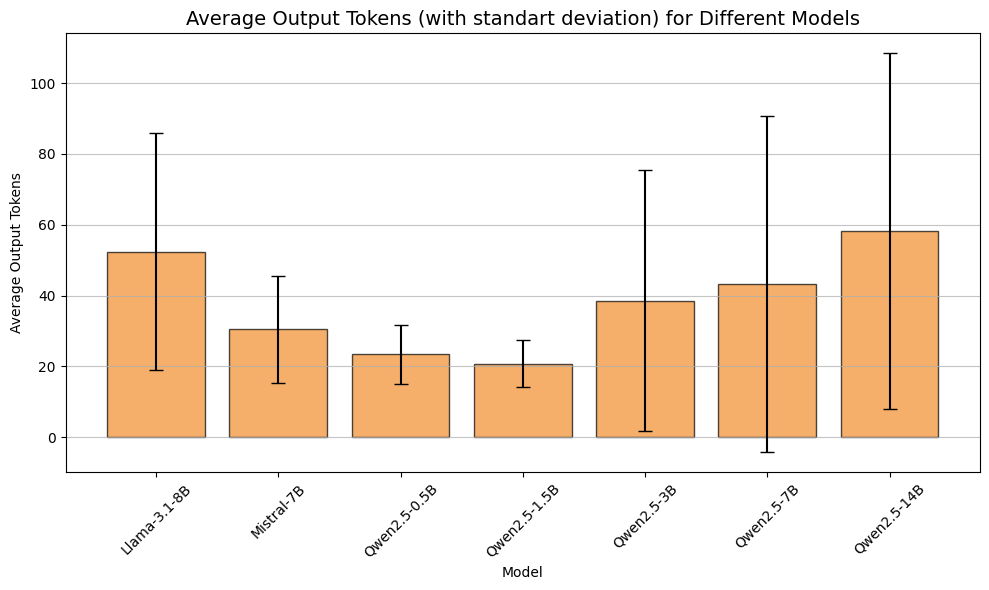

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ajoute une colonne 'Params (B)' à chaque DataFrame individuel
df_qwen0_5B['Params (B)'] = 0.5
df_qwen1_5B['Params (B)'] = 1.5
df_qwen3B['Params (B)'] = 3
df_qwen7B['Params (B)'] = 7
df_qwen14B['Params (B)'] = 14
df_mistral7B['Params (B)'] = 7
df_llama8B['Params (B)'] = 8

# Ajoute aussi la colonne "Model" si besoin (pour légende ou color mapping)
df_qwen0_5B['Model'] = 'Qwen 0.5B'
df_qwen1_5B['Model'] = 'Qwen 1.5B'
df_qwen3B['Model'] = 'Qwen 3B'
df_qwen7B['Model'] = 'Qwen 7B'
df_qwen14B['Model'] = 'Qwen 14B'
df_mistral7B['Model'] = 'Mistral 7B'
df_llama8B['Model'] = 'Llama 8B'

# Concatène tous les DataFrames
df_all = pd.concat([
    df_qwen0_5B,
    df_qwen1_5B,
    df_qwen3B,
    df_qwen7B,
    df_qwen14B,
    df_mistral7B,
    df_llama8B
])

# Convertit l'énergie en Wh
df_all['Energy (Wh)'] = df_all['energy_generate_gpu'] * 1000
df_all['Energy prefill (Wh)'] = df_all['energy_prefill_gpu'] * 1000
df_all['Energy decode (Wh)'] = df_all['energy_decode_gpu'] * 1000

colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']
fig, ax = plt.subplots(figsize=(10, 6))
models = ['Llama-3.1-8B', 'Mistral-7B', 'Qwen2.5-0.5B', 'Qwen2.5-1.5B', 'Qwen2.5-3B', 'Qwen2.5-7B', 'Qwen2.5-14B']
output_tokens = [
    df_llama8B['response_tokens'].mean(),
    df_mistral7B['response_tokens'].mean(),
    df_qwen0_5B['response_tokens'].mean(),
    df_qwen1_5B['response_tokens'].mean(),
    df_qwen3B['response_tokens'].mean(),
    df_qwen7B['response_tokens'].mean(),
    df_qwen14B['response_tokens'].mean()
]
var_output_tokens = [
    df_llama8B['response_tokens'].std(),
    df_mistral7B['response_tokens'].std(),
    df_qwen0_5B['response_tokens'].std(),
    df_qwen1_5B['response_tokens'].std(),
    df_qwen3B['response_tokens'].std(),
    df_qwen7B['response_tokens'].std(),
    df_qwen14B['response_tokens'].std()
]
ax.bar(models, output_tokens, yerr=var_output_tokens, capsize=5, color=colors[1], alpha=0.7, edgecolor='black')
ax.set_title('Average Output Tokens (with standart deviation) for Different Models', fontsize=14)
ax.set_ylabel('Average Output Tokens')
ax.set_xlabel('Model')
ax.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


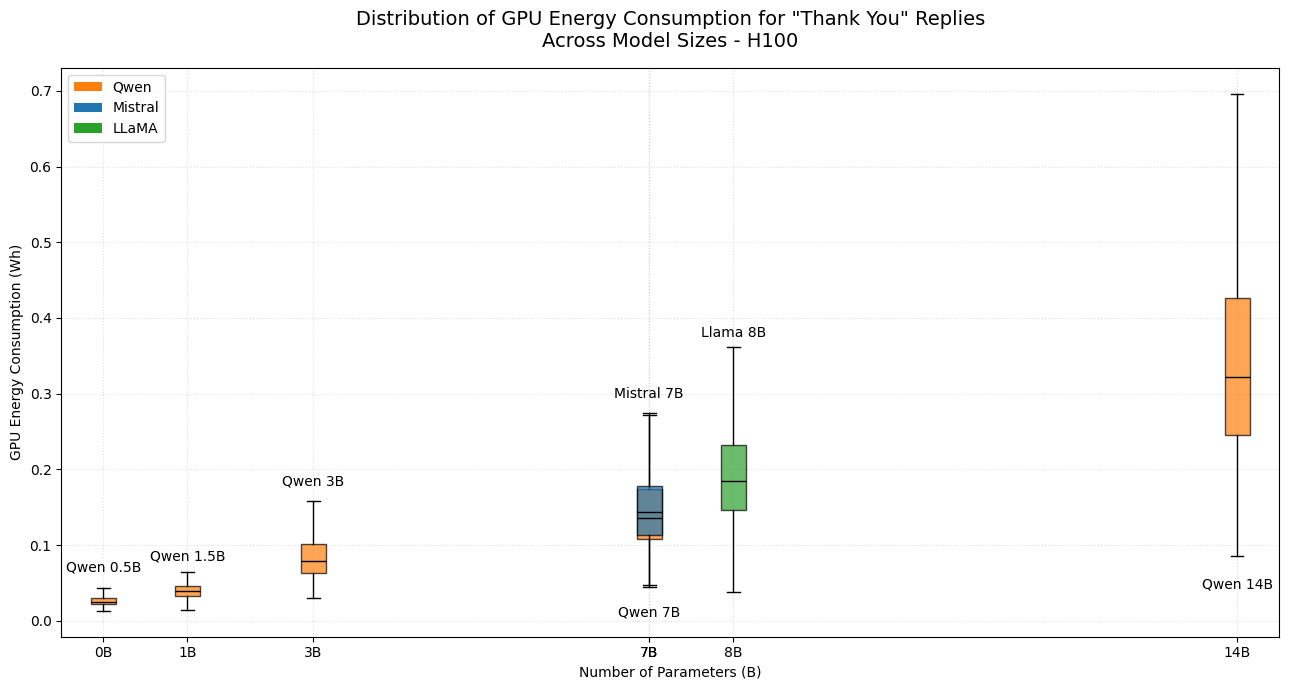

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

param_counts = [0.5e9, 1.5e9, 3e9, 7e9, 14e9, 7e9, 8e9]
model_names = ['Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B', 'Qwen 7B', 'Qwen 14B', 'Mistral 7B', 'Llama 8B']
colors = ['tab:orange'] * 5 + ['tab:blue', 'tab:green']
label_offsets = [
    (0, 0.04), (0, 0.04), (0, 0.1), (0, -0.13),
    (0, -0.28), (0, 0.15), (0, 0.19),
]

energy_gpu_values = [
    (df_qwen0_5B['energy_generate_gpu'] * 1000).tolist(),
    (df_qwen1_5B['energy_generate_gpu'] * 1000).tolist(),
    (df_qwen3B['energy_generate_gpu'] * 1000).tolist(),
    (df_qwen7B['energy_generate_gpu'] * 1000).tolist(),
    (df_qwen14B['energy_generate_gpu'] * 1000).tolist(),
    (df_mistral7B['energy_generate_gpu'] * 1000).tolist(),
    (df_llama8B['energy_generate_gpu'] * 1000).tolist()
]

sorted_data = sorted(
    zip(param_counts, energy_gpu_values, model_names, colors, label_offsets),
    key=lambda x: x[0]
)

fig, ax = plt.subplots(figsize=(13, 7))
for i, (param, energy_vals, name, color, (dx, dy)) in enumerate(sorted_data):
    x = param / 1e9
    median = np.median(energy_vals)
    ax.boxplot(energy_vals, positions=[x], widths=0.3,
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black'), showfliers=False)
    ax.text(x + dx, median + dy, name, ha='center', fontsize=10)

xticks = [p / 1e9 for p, *_ in sorted_data]
xticklabels = [f"{int(p/1e9)}B" for p, *_ in sorted_data]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

ax.set_xlabel('Number of Parameters (B)')
ax.set_ylabel('GPU Energy Consumption (Wh)')
ax.set_title('Distribution of GPU Energy Consumption for "Thank You" Replies\nAcross Model Sizes - H100', fontsize=14, pad=15)
ax.grid(True, linestyle=':', alpha=0.4)

legend_elements = [
    Patch(facecolor='tab:orange', label='Qwen'),
    Patch(facecolor='tab:blue', label='Mistral'),
    Patch(facecolor='tab:green', label='LLaMA'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()



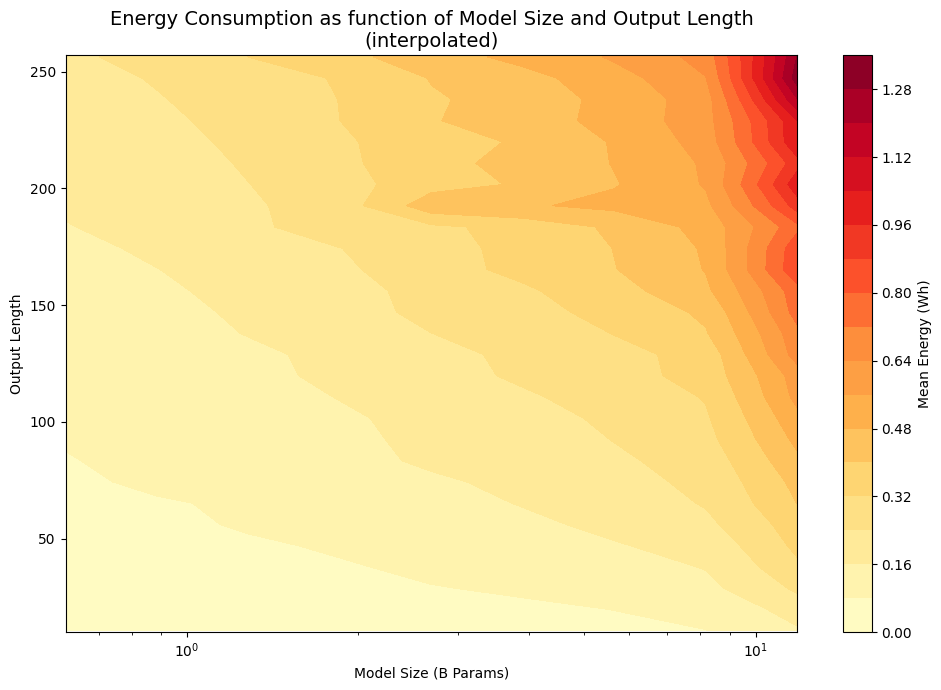

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic_2d
from scipy.interpolate import griddata

bins_params = np.logspace(np.log10(df_all['Params (B)'].min()), np.log10(df_all['Params (B)'].max()), 10)
bins_outlen = np.linspace(df_all['response_tokens'].min(), df_all['response_tokens'].max(), 40)

stat, x_edge, y_edge, _ = binned_statistic_2d(
    df_all['Params (B)'],
    df_all['response_tokens'],
    df_all['Energy (Wh)'],
    statistic='mean',
    bins=[bins_params, bins_outlen]
)

x_centers = (x_edge[:-1] + x_edge[1:]) / 2
y_centers = (y_edge[:-1] + y_edge[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)

points = np.array([X[~np.isnan(stat.T)], Y[~np.isnan(stat.T)]]).T
values = stat.T[~np.isnan(stat.T)]
stat_interp = griddata(points, values, (X, Y), method='linear')

plt.figure(figsize=(10, 7))
contour = plt.contourf(X, Y, stat_interp, levels=20, cmap="YlOrRd")
plt.colorbar(contour, label='Mean Energy (Wh)')
plt.xlabel('Model Size (B Params)')
plt.ylabel('Output Length')
plt.xscale('log')
plt.ylim(10, 257)
plt.title('Energy Consumption as function of Model Size and Output Length\n(interpolated)', fontsize=14)
plt.tight_layout()
plt.show()
